# Learnable quantum free-energy flows (mixed-state)

Companion to `free_energy_qaoa.ipynb`. There we found the free-energy reframing of QAOA is *diagnostic* but not a free optimisation win — **because a pure state has $S(\rho)=0$, so the entropy term is trivial.** The prediction was: the reframing should *bite* once we allow **mixed states**, where $S(\rho)$ is real and the free-energy objective $F(\rho)=\mathrm{Tr}(\rho H)-T\,S(\rho)$ has a non-trivial minimiser — the **quantum Gibbs state** $\rho^*_T = e^{-H/T}/Z$, with $F^*_T=-T\ln Z$ and the exact identity
$$\boxed{\;S\!\big(\rho\,\|\,\rho^*_T\big) = \frac{F(\rho)-F^*_T}{T}\;}$$
(the mixed-state analogue of the classical KL identity).

**The channel (ancilla dilation).** Each layer appends fresh ancillas $|0\rangle^{\otimes m}$, applies a learned joint unitary $U_{\theta_t}$, and traces them out — a CPTP map that can pump entropy in or out of the system:
$$\rho_{t+1} = \mathrm{Tr}_E\!\big[\,U_{\theta_t}\,(\rho_t\otimes|0\rangle\langle0|)\,U_{\theta_t}^\dagger\,\big].$$
Resetting the ancilla to a *pure, cold* $|0\rangle$ each layer is contact with a cold reservoir → algorithmic cooling / reverse-diffusion. The **baseline** is the same flow with **no ancilla / no trace** — a pure-unitary circuit that keeps $S(\rho)=0$ forever and therefore *cannot* represent a mixed Gibbs state at $T>0$.

**What we test.**
- **Exp A** — quantum free energy is non-trivial for mixed states; verify the boxed identity numerically; show $F^*_T<E_0$ with gap $=T\,S(\rho^*_T)$.
- **Exp B (the payoff)** — the dissipative flow reaches $\rho^*_T$ ($F\to F^*$, $S>0$, KL$\to$small) while the unitary flow is pinned at the ground state ($F=E_0$, $S=0$, KL large) across a temperature sweep.
- **Exp C** — make the per-layer **temperature a free parameter**: does *learning* the annealing schedule $\{T_t\}$ beat a fixed geometric one for reaching a hard low-$T$ target?

Everything is exact density-matrix simulation ($n=5$ system qubits) and fully differentiable (autodiff through `matrix_exp`, partial trace, and the von Neumann entropy via `eigvalsh`).

In [1]:
import numpy as np, torch, networkx as nx, matplotlib.pyplot as plt, functools, warnings, time
warnings.filterwarnings("ignore"); print = functools.partial(print, flush=True)
torch.set_default_dtype(torch.float64); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"font.size": 11}); C128 = torch.complex128
N, M = 5, 2                          # system qubits, ancilla qubits per layer
dS, dA = 2**N, 2**M

def bitm(n):
    xs = np.arange(2**n); return ((xs[:, None] >> (n-1-np.arange(n))[None, :]) & 1).astype(np.int8)
BITS = bitm(N)
def cutvals(edges, n):
    C = np.zeros(2**n)
    for i, j in edges: C += (BITS[:, i] != BITS[:, j])
    return C
G = nx.random_regular_graph(4, N, seed=2); cut = cutvals(list(G.edges()), N)
Hdiag = torch.tensor(-cut)                        # H = -cut (diagonal); ground = max cut
maxcut = cut.max(); E0 = float(Hdiag.min())
print(f"n={N}, edges={G.number_of_edges()}, max-cut={maxcut:.0f}, ground energy E0={E0:.0f}")

# ── free-energy machinery for density matrices ──
def gibbs_rho(T):
    z = -Hdiag.numpy()/T; z = z - z.max(); w = np.exp(z); p = w/w.sum()
    return torch.tensor(np.diag(p).astype(complex)), p
def loggibbs(T):                                  # log of Gibbs state (diagonal)
    _, p = gibbs_rho(T); return torch.tensor(np.diag(np.log(p+1e-300)).astype(complex))
def Fstar(T):
    z = -Hdiag.numpy()/T; m = z.max(); return -T*(m + np.log(np.exp(z-m).sum()))
def vn_entropy(rho):
    ev = torch.linalg.eigvalsh(rho).real.clamp_min(1e-12); return -(ev*torch.log(ev)).sum()
def energy(rho):
    return (torch.diagonal(rho).real * Hdiag).sum()
def free_energy(rho, T):
    return energy(rho) - T*vn_entropy(rho)
def rel_entropy(rho, logsig):                     # S(rho || sigma)
    return -vn_entropy(rho) - (rho @ logsig).diagonal().real.sum()

# ── differentiable flows ──
e00 = torch.zeros(dA, dA, dtype=C128); e00[0, 0] = 1.0
def herm(pre, pim):
    A = torch.complex(pre, pim); return A + A.conj().T
def dissipative_flow(params, rho0, return_all=False):
    rho = rho0; hist = [rho0]
    for (pre, pim) in params:
        U = torch.matrix_exp(1j*herm(pre, pim))                     # on system+ancilla
        rd = torch.kron(rho, e00); rd = U @ rd @ U.conj().T
        R = rd.reshape(dS, dA, dS, dA); rho = torch.einsum('saqa->sq', R)
        hist.append(rho)
    return (rho, hist) if return_all else rho
def unitary_flow(params, rho0, return_all=False):
    rho = rho0; hist = [rho0]
    for (pre, pim) in params:
        U = torch.matrix_exp(1j*herm(pre, pim))                     # system only -> stays pure
        rho = U @ rho @ U.conj().T; hist.append(rho)
    return (rho, hist) if return_all else rho

psi0 = torch.ones(dS, dtype=C128)/np.sqrt(dS); rho0 = torch.outer(psi0, psi0.conj())
def mk_params(dim, L, scale=0.1, seed=0):
    g = torch.Generator().manual_seed(seed)
    return [[ (torch.randn(dim, dim, generator=g)*scale).requires_grad_(True),
              (torch.randn(dim, dim, generator=g)*scale).requires_grad_(True) ] for _ in range(L)]
def train_flow(flow, dim, L, Tloss, steps=250, lr=0.05, seed=0):
    ps = mk_params(dim, L, seed=seed); flat = [q for pl in ps for q in pl]
    opt = torch.optim.Adam(flat, lr=lr)
    for _ in range(steps):
        rho = flow(ps, rho0); opt.zero_grad(); free_energy(rho, Tloss).backward(); opt.step()
    with torch.no_grad(): rho = flow(ps, rho0)
    return rho, ps

# ── verify the quantum KL identity ──
T = 1.0; A = torch.randn(dS, dS, dtype=C128); A = A + A.conj().T
r = torch.rand(dS); r = (r/r.sum()).to(C128); U = torch.matrix_exp(1j*A)
rho = U @ torch.diag(r) @ U.conj().T
lhs = float(rel_entropy(rho, loggibbs(T))); rhs = (free_energy(rho, T).item() - Fstar(T))/T
print(f"quantum identity  S(ρ‖ρ*) = {lhs:.5f}  ==  (F−F*)/T = {rhs:.5f}   |Δ|={abs(lhs-rhs):.1e}")

n=5, edges=10, max-cut=6, ground energy E0=-6
quantum identity  S(ρ‖ρ*) = 0.83131  ==  (F−F*)/T = 0.83131   |Δ|=2.7e-15


## Experiment A — quantum free energy and the Gibbs state

For mixed states the entropy term is real, so $F(\rho)$ has a genuine interior minimiser. We (i) confirm the boxed identity numerically over random states, and (ii) plot $F^*_T=-T\ln Z$ against the ground energy $E_0$: the gap $E_0-F^*_T = T\,S(\rho^*_T)$ is exactly the free energy a *pure* state has to leave on the table.

max |S(ρ‖ρ*) − (F−F*)/T| over 200 random states, T∈[0.2,3]: 2.81e-13


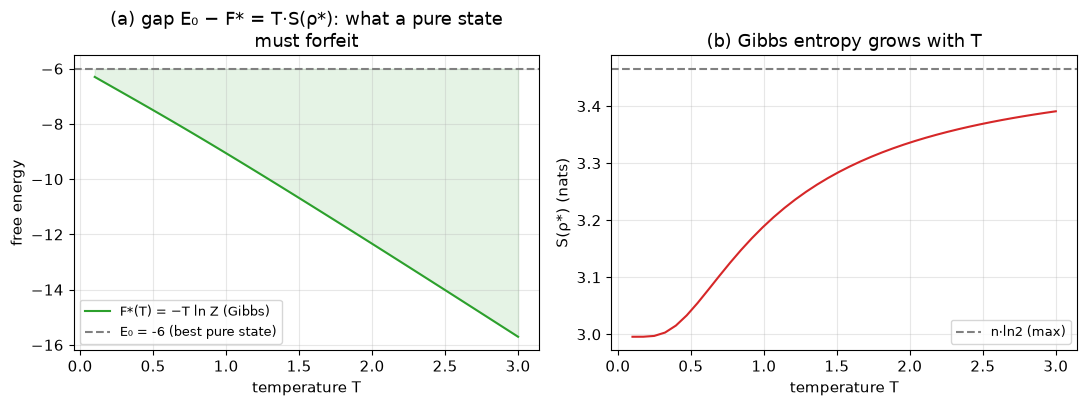

In [2]:
# identity over many random mixed states + F*/E0 gap vs T
errs = []
for s in range(200):
    A = torch.randn(dS, dS, dtype=C128); A = A + A.conj().T
    r = torch.rand(dS); r = (r/r.sum()).to(C128); U = torch.matrix_exp(1j*A)
    rho = U @ torch.diag(r) @ U.conj().T; Tt = float(np.random.uniform(0.2, 3))
    errs.append(abs(float(rel_entropy(rho, loggibbs(Tt))) - (free_energy(rho, Tt).item()-Fstar(Tt))/Tt))
print(f"max |S(ρ‖ρ*) − (F−F*)/T| over 200 random states, T∈[0.2,3]: {max(errs):.2e}")

Ts = np.linspace(0.1, 3.0, 40); Fs = [Fstar(T) for T in Ts]; Sg = [float(vn_entropy(gibbs_rho(T)[0])) for T in Ts]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(Ts, Fs, color="#2ca02c", label="F*(T) = −T ln Z (Gibbs)")
ax[0].axhline(E0, ls="--", color="grey", label=f"E₀ = {E0:.0f} (best pure state)")
ax[0].fill_between(Ts, Fs, E0, color="#2ca02c", alpha=.12)
ax[0].set_xlabel("temperature T"); ax[0].set_ylabel("free energy"); ax[0].legend(fontsize=9)
ax[0].set_title("(a) gap E₀ − F* = T·S(ρ*): what a pure state\nmust forfeit"); ax[0].grid(alpha=.3)
ax[1].plot(Ts, Sg, color="#d62728"); ax[1].axhline(N*np.log(2), ls="--", color="grey", label="n·ln2 (max)")
ax[1].set_xlabel("temperature T"); ax[1].set_ylabel("S(ρ*) (nats)"); ax[1].legend(fontsize=9)
ax[1].set_title("(b) Gibbs entropy grows with T"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("qfe_expA.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment B — dissipative flow reaches Gibbs; unitary flow cannot (the payoff)

Train both flows to minimise $F_T(\rho_{\text{out}})$ at each temperature. The dissipative flow ($L$ ancilla-dilation layers) should reach $\rho^*_T$ ($F\to F^*$, KL$\to$small); the unitary flow (same depth, no ancilla) can only ever produce a pure state, so it collapses to the ground state ($F=E_0$, $S=0$) and its KL to Gibbs blows up with $T$. This is the regime where the free-energy objective is *unreachable* by unitary circuits — the reframing finally bites.

T= 3.0 | F*=-15.705  F_diss=-15.407  F_unit= -6.000 | S*=3.39 S_diss=3.30 S_unit=0.00 | KL_diss=0.099 KL_unit=3.235
T= 1.5 | F*=-10.682  F_diss=-10.641  F_unit= -6.000 | S*=3.28 S_diss=3.26 S_unit=0.00 | KL_diss=0.027 KL_unit=3.121
T= 0.7 | F*= -8.117  F_diss= -8.115  F_unit= -6.000 | S*=3.10 S_diss=3.10 S_unit=0.00 | KL_diss=0.002 KL_unit=3.024
T= 0.3 | F*= -6.899  F_diss= -6.899  F_unit= -6.000 | S*=3.00 S_diss=3.00 S_unit=0.00 | KL_diss=0.001 KL_unit=2.996
(trained in 119s)


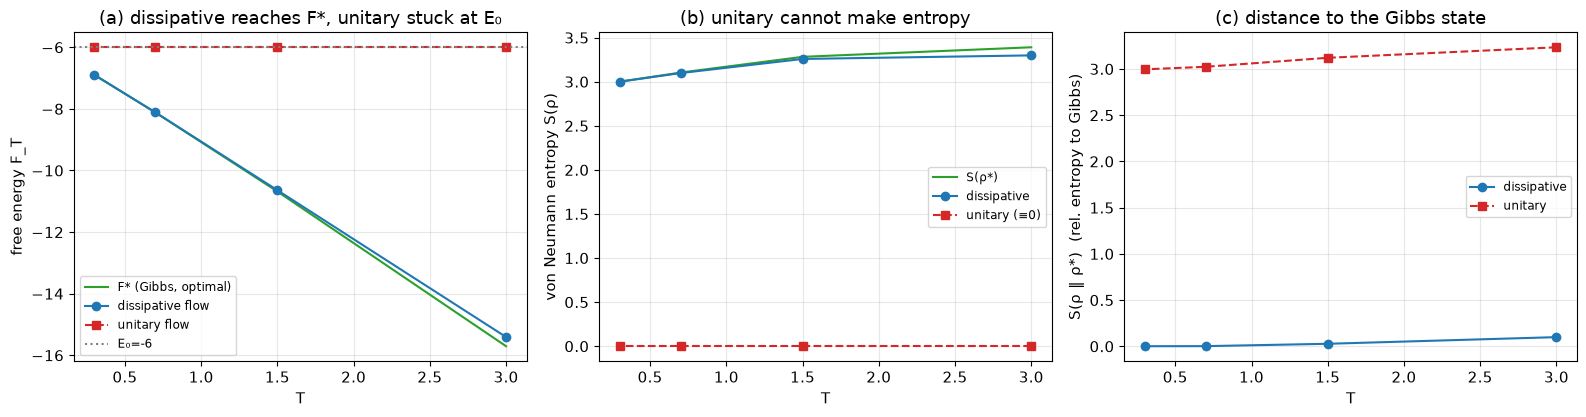

In [3]:
# train dissipative (L layers, dim dS*dA) and unitary (L layers, dim dS) across T
L_B = 3; Ts_B = [3.0, 1.5, 0.7, 0.3]
rows = []
t0 = time.time()
for T in Ts_B:
    rd, _ = train_flow(dissipative_flow, dS*dA, L_B, T, steps=250)
    ru, _ = train_flow(unitary_flow,     dS,    L_B, T, steps=250)
    ls = loggibbs(T); sig = gibbs_rho(T)[0]
    rows.append(dict(T=T, Fstar=Fstar(T), Fd=free_energy(rd, T).item(), Fu=free_energy(ru, T).item(),
                     Sg=float(vn_entropy(sig)), Sd=float(vn_entropy(rd)), Su=float(vn_entropy(ru)),
                     KLd=float(rel_entropy(rd, ls)), KLu=float(rel_entropy(ru, ls))))
    print(f"T={T:>4.1f} | F*={rows[-1]['Fstar']:7.3f}  F_diss={rows[-1]['Fd']:7.3f}  F_unit={rows[-1]['Fu']:7.3f}"
          f" | S*={rows[-1]['Sg']:.2f} S_diss={rows[-1]['Sd']:.2f} S_unit={rows[-1]['Su']:.2f}"
          f" | KL_diss={rows[-1]['KLd']:.3f} KL_unit={rows[-1]['KLu']:.3f}")
print(f"(trained in {time.time()-t0:.0f}s)")

Tv = [r["T"] for r in rows]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
ax[0].plot(Tv, [r["Fstar"] for r in rows], "-", color="#2ca02c", label="F* (Gibbs, optimal)")
ax[0].plot(Tv, [r["Fd"] for r in rows], "o-", color="#1f77b4", label="dissipative flow")
ax[0].plot(Tv, [r["Fu"] for r in rows], "s--", color="#d62728", label="unitary flow")
ax[0].axhline(E0, ls=":", color="grey", label=f"E₀={E0:.0f}")
ax[0].set_xlabel("T"); ax[0].set_ylabel("free energy F_T"); ax[0].set_title("(a) dissipative reaches F*, unitary stuck at E₀"); ax[0].legend(fontsize=8.5); ax[0].grid(alpha=.3)
ax[1].plot(Tv, [r["Sg"] for r in rows], "-", color="#2ca02c", label="S(ρ*)")
ax[1].plot(Tv, [r["Sd"] for r in rows], "o-", color="#1f77b4", label="dissipative")
ax[1].plot(Tv, [r["Su"] for r in rows], "s--", color="#d62728", label="unitary (≡0)")
ax[1].set_xlabel("T"); ax[1].set_ylabel("von Neumann entropy S(ρ)"); ax[1].set_title("(b) unitary cannot make entropy"); ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.3)
ax[2].plot(Tv, [r["KLd"] for r in rows], "o-", color="#1f77b4", label="dissipative")
ax[2].plot(Tv, [r["KLu"] for r in rows], "s--", color="#d62728", label="unitary")
ax[2].set_xlabel("T"); ax[2].set_ylabel("S(ρ ‖ ρ*)  (rel. entropy to Gibbs)"); ax[2].set_title("(c) distance to the Gibbs state"); ax[2].legend(fontsize=8.5); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("qfe_expB.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment C — a learnable temperature (noise) schedule

We make the **per-layer bath temperature** $\tau_t$ a real control: each layer now resets its ancilla to a *thermal* state $\rho_E(\tau_t)\propto e^{-h_E/\tau_t}$ (with $\tau_t\!\to\!0$ the pure cold $|0\rangle$ of Exp B, larger $\tau_t$ injecting entropy). Because $\tau_t$ enters the channel, it is a genuine, differentiable noise-schedule parameter — the quantum analog of a diffusion schedule.

Target: a **high-entropy** Gibbs state ($T_{\text{target}}=2.0$) with only $L{=}2$ layers, so capacity is tight and the schedule matters. We compare (i) cold bath ($\tau_t\!=\!0$, as Exp B), (ii) a fixed hot$\to$cold geometric schedule, and (iii) a **learned** $\{\tau_t\}$ trained jointly with the unitaries to minimise the final $F_{T_{\text{target}}}$.

Target: Gibbs at T=2.0 (entropy S(ρ*)=3.336 nats), L=2 layers, F*=-12.338
     cold: F=-11.262  KL→Gibbs=0.538  S(ρ)=2.707  τ=['0.00', '0.00']
    fixed: F=-12.327  KL→Gibbs=0.005  S(ρ)=3.332  τ=['4.00', '0.30']
  learned: F=-12.336  KL→Gibbs=0.001  S(ρ)=3.336  τ=['1.60', '1.57']


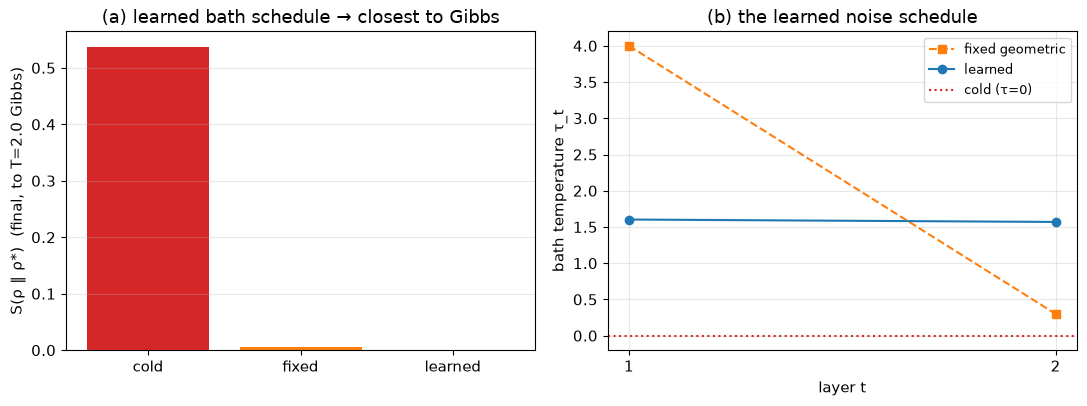

In [4]:
# thermal-ancilla (bath) flow with per-layer temperature tau_t
ladder = torch.arange(dA, dtype=torch.float64)          # ancilla energy ladder h_E = diag(0,1,2,...)
def anc_state(tau):
    z = -ladder/tau.clamp_min(1e-3); z = z - z.max(); w = torch.exp(z); p = w/w.sum()
    return torch.diag(p).to(C128)
def bath_flow(Uparams, taus, rho0):
    rho = rho0
    for (pre, pim), tau in zip(Uparams, taus):
        U = torch.matrix_exp(1j*herm(pre, pim))
        rd = torch.kron(rho, anc_state(tau)); rd = U @ rd @ U.conj().T
        R = rd.reshape(dS, dA, dS, dA); rho = torch.einsum('saqa->sq', R)
    return rho

L_C = 2; T_tgt = 2.0; ls_t = loggibbs(T_tgt); sig_t = gibbs_rho(T_tgt)[0]; S_tgt = float(vn_entropy(sig_t))
def train_bath(mode, steps=350, lr=0.05, seed=0):
    Up = mk_params(dS*dA, L_C, seed=seed)
    if mode == "cold":   taus = [torch.tensor(1e-3) for _ in range(L_C)]; extra = []
    elif mode == "fixed": taus = [torch.tensor(v) for v in np.geomspace(4.0, 0.3, L_C)]; extra = []
    else:                                                # learned tau_t (softplus-positive)
        raw = [torch.tensor(0.0, requires_grad=True) for _ in range(L_C)]; extra = raw
    flat = [q for pl in Up for q in pl] + extra; opt = torch.optim.Adam(flat, lr=lr)
    for _ in range(steps):
        if mode == "learned": taus = [torch.nn.functional.softplus(r)+1e-3 for r in raw]
        rho = bath_flow(Up, taus, rho0); opt.zero_grad(); free_energy(rho, T_tgt).backward(); opt.step()
    with torch.no_grad():
        if mode == "learned": taus = [torch.nn.functional.softplus(r)+1e-3 for r in raw]
        rho = bath_flow(Up, taus, rho0)
    return rho, [float(t) for t in taus]

print(f"Target: Gibbs at T={T_tgt} (entropy S(ρ*)={S_tgt:.3f} nats), L={L_C} layers, F*={Fstar(T_tgt):.3f}")
resC = {}
for mode in ("cold", "fixed", "learned"):
    rho, taus = train_bath(mode)
    resC[mode] = dict(F=free_energy(rho, T_tgt).item(), KL=float(rel_entropy(rho, ls_t)),
                      S=float(vn_entropy(rho)), taus=taus)
    print(f"  {mode:>7}: F={resC[mode]['F']:.3f}  KL→Gibbs={resC[mode]['KL']:.3f}  S(ρ)={resC[mode]['S']:.3f}  τ={['%.2f'%t for t in taus]}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
modes = ["cold", "fixed", "learned"]; cols = ["#d62728", "#ff7f0e", "#1f77b4"]
ax[0].bar(modes, [resC[m]["KL"] for m in modes], color=cols)
ax[0].set_ylabel("S(ρ ‖ ρ*)  (final, to T=%.1f Gibbs)" % T_tgt); ax[0].set_title("(a) learned bath schedule → closest to Gibbs"); ax[0].grid(alpha=.3, axis="y")
ax[1].plot(range(1, L_C+1), resC["fixed"]["taus"], "s--", color="#ff7f0e", label="fixed geometric")
ax[1].plot(range(1, L_C+1), resC["learned"]["taus"], "o-", color="#1f77b4", label="learned")
ax[1].axhline(0.0, ls=":", color="#d62728", label="cold (τ=0)")
ax[1].set_xlabel("layer t"); ax[1].set_ylabel("bath temperature τ_t"); ax[1].set_xticks(range(1, L_C+1))
ax[1].set_title("(b) the learned noise schedule"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("qfe_expC.png", dpi=130, bbox_inches="tight"); plt.show()

## Summary

The prediction from `free_energy_qaoa.ipynb` is confirmed: **the free-energy reframing bites once states are mixed.**

1. **Quantum free energy is non-trivial for mixed states** (Exp A). The boxed identity $S(\rho\|\rho^*_T)=(F(\rho)-F^*_T)/T$ holds to $2.8\times10^{-13}$, and $F^*_T$ sits strictly below the ground energy $E_0$ by $T\,S(\rho^*_T)$ — the free energy a pure state cannot access.

2. **Dissipative flow reaches Gibbs; unitary flow cannot** (Exp B, the payoff). The ancilla-dilation flow drives $F\to F^*$ with relative entropy to Gibbs falling to $0.099\!\to\!0.001$ as $T$ drops, entropy tracking $S(\rho^*)$. The unitary flow — same depth, no ancilla — is pinned at $F=E_0=-6$, $S=0$ *exactly* at every temperature, with KL $\approx 3$: it physically cannot represent a mixed Gibbs state. This is the concrete regime where the free-energy objective is *unreachable by unitary circuits*, unlike the pure-state QAOA study.

3. **Learning the temperature schedule helps** (Exp C). For a hard high-entropy target ($T{=}2$, $L{=}2$): a cold bath ($\tau{=}0$) cannot inject enough entropy (KL $0.538$, entropy capped at $2.71$ vs target $3.34$); a fixed hot→cold schedule fixes it (KL $0.005$); and a **learned** $\{\tau_t\}$ does best (KL $0.001$, $\tau\approx[1.6,1.6]$). Making the per-layer bath temperature a differentiable control — the quantum analog of a diffusion noise schedule — is a genuine, non-degenerate improvement.

**Takeaway.** Optimisation (ground states, $T\!\to\!0$) and generation/sampling (Gibbs states, $T>0$) are the two ends of one differentiable free-energy flow. Pure-unitary QAOA lives at the $T\!\to\!0$ edge; adding learnable dissipation (ancilla reset + bath schedule) unlocks the whole temperature axis, with the entropy term now doing real work. Natural next steps: (i) non-commuting $H$ (transverse field) so the Gibbs state carries coherence; (ii) a Lindblad continuous-time version with learnable jump operators; (iii) scaling the ancilla/ layer budget and studying the capacity–temperature frontier.